# Data Cleaning

## Import

In [1]:
# packages
import pandas as pd
pd.set_option("display.max_columns", 100)

import numpy as np

# graphs
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 14

import seaborn as sns

# package perso
from titanic.eda import stats, describe_numeric
from titanic.data import load_interim_data

## Data loading

In [4]:
df = load_interim_data("../data/interim/titanic_merged.parquet")

print(df.shape)
df.head()

(1309, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset overview

In [3]:
stats(df)

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,int64,1309,0 (0%),1309,1,1,655.0,378.020061,1.0,328.0,655.0,982.0,1309.0
Survived,float64,891,418 (32%),2,0.0,549,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,int64,1309,0 (0%),3,3,709,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
Name,str,1309,0 (0%),1307,"Connolly, Miss. Kate",2,/,/,/,/,/,/,/
Sex,str,1309,0 (0%),2,male,843,/,/,/,/,/,/,/
Age,float64,1046,263 (21%),98,24.0,47,29.881138,14.413493,0.17,21.0,28.0,39.0,80.0
SibSp,int64,1309,0 (0%),7,0,891,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
Parch,int64,1309,0 (0%),8,0,1002,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
Ticket,str,1309,0 (0%),929,CA. 2343,11,/,/,/,/,/,/,/
Fare,float64,1308,1 (1%),281,8.05,60,33.295479,51.758668,0.0,7.8958,14.4542,31.275,512.3292


---

## Data cleaning

### PassengerId

In [4]:
display(stats(df).loc[["PassengerId"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,int64,1309,0 (0%),1309,1,1,655.0,378.020061,1.0,328.0,655.0,982.0,1309.0


- 0 null
- 0 doublons
> OK

### Pclass

In [5]:
df["Pclass"].sample(10, random_state=42)

1148    3
1049    1
982     3
808     2
1195    3
240     3
1118    3
596     2
924     3
65      3
Name: Pclass, dtype: int64

In [6]:
display(stats(df).loc[["Pclass"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Pclass,int64,1309,0 (0%),3,3,709,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0


In [7]:
df["Pclass"].value_counts().sort_index()

Pclass
1    323
2    277
3    709
Name: count, dtype: int64

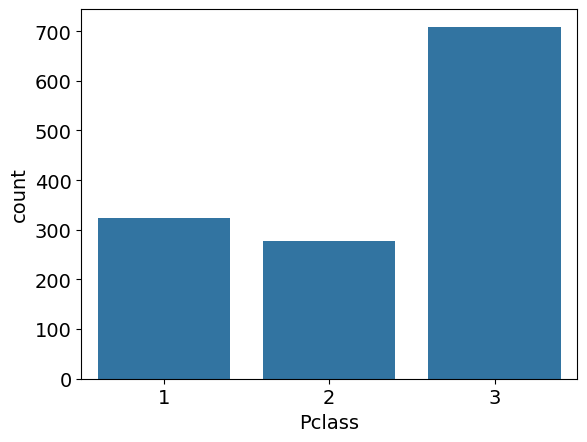

In [8]:
sns.countplot(data=df, x="Pclass")
plt.show()

- La variable Pclass ne présente aucune valeur manquante.
- Les modalités observées sont conformes à la documentation du dataset (1, 2 et 3).
- Aucune valeur aberrante ou incohérente n'a été détectée.
- Aucun nettoyage supplémentaire n'est nécessaire.

### Name

In [9]:
df["Name"].sample(10, random_state=42)

1148                                Niklasson, Mr. Samuel
1049                             Borebank, Mr. John James
982                                    Pedersen, Mr. Olaf
808                                     Meyer, Mr. August
1195                    McCarthy, Miss. Catherine Katie""
240                                 Zabour, Miss. Thamine
1118                               McNeill, Miss. Bridget
596                            Leitch, Miss. Jessie Wills
924     Johnston, Mrs. Andrew G (Elizabeth Lily" Watson)"
65                               Moubarek, Master. Gerios
Name: Name, dtype: str

In [10]:
display(stats(df).loc[["Name"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,str,1309,0 (0%),1307,"Connolly, Miss. Kate",2,/,/,/,/,/,/,/


In [11]:
# doublons
df.loc[df["Name"].duplicated(keep=False)].sort_values("Name")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
289,290,1.0,3,"Connolly, Miss. Kate",female,22.0,0,0,370373,7.7500,NaN,Q
897,898,NaN,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
696,697,0.0,3,"Kelly, Mr. James",male,44.0,0,0,363592,8.0500,NaN,S
891,892,NaN,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q


In [12]:
# nom vide ?
df.loc[df["Name"].str.strip() == ""]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [13]:
# présence d’une virgule ?
df.loc[~df["Name"].str.contains(",", na=False)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [14]:
# présence d’un point ?
df.loc[~df["Name"].str.contains(r"\.", regex=True, na=False)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [15]:
# caractère particulier
df.loc[df["Name"].str.contains(r"[^a-zA-ZÀ-ÿ0-9 ,.'()\-]", regex=True, na=False)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
22,23,1.0,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
28,29,1.0,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
101,102,0.0,3,"Petroff, Mr. Pastcho (""Pentcho"")",male,NaN,0,0,349215,7.8958,NaN,S
146,147,1.0,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
147,148,0.0,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.3750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1258,1259,NaN,3,"Riihivouri, Miss. Susanna Juhantytar Sanni""""",female,22.0,0,0,3101295,39.6875,NaN,S
1268,1269,NaN,2,"Cotterill, Mr. Henry Harry""""",male,21.0,0,0,29107,11.5000,NaN,S
1275,1276,NaN,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S
1296,1297,NaN,2,"Nourney, Mr. Alfred (Baron von Drachstedt"")""",male,20.0,0,0,SC/PARIS 2166,13.8625,D38,C


- La variable Name ne contient aucune valeur manquante.
- Chaque observation correspond à un nom de passager au format « Nom, Titre. Prénom ».
- Aucun doublon exact ni anomalie de format majeure n'a été détecté.
- La variable semble propre et exploitable pour de futures étapes de feature engineering (extraction du titre, du nom de famille ou d'éventuels indicateurs textuels).

### Sex

In [16]:
df["Sex"].sample(10, random_state=42)

1148      male
1049      male
982       male
808       male
1195    female
240     female
1118    female
596     female
924     female
65        male
Name: Sex, dtype: str

In [17]:
display(stats(df).loc[["Sex"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Sex,str,1309,0 (0%),2,male,843,/,/,/,/,/,/,/


In [18]:
df["Sex"].value_counts().sort_index()

Sex
female    466
male      843
Name: count, dtype: int64

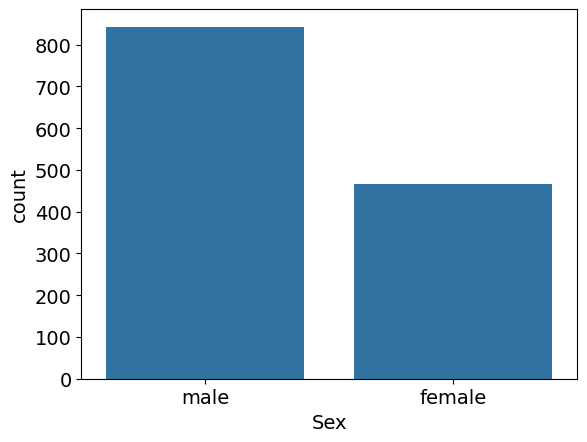

In [19]:
sns.countplot(data=df, x="Sex")
plt.show()

- La variable Sex ne contient aucune valeur manquante.
- Les deux modalités observées (male et female) sont conformes à la documentation du dataset.
- Aucun problème de formatage ou de normalisation n'a été détecté.
- Aucun nettoyage supplémentaire n'est nécessaire.

### Age

In [20]:
df["Age"].sample(10, random_state=42)

1148    28.0
1049    42.0
982      NaN
808     39.0
1195     NaN
240      NaN
1118     NaN
596      NaN
924      NaN
65       NaN
Name: Age, dtype: float64

In [21]:
display(stats(df).loc[["Age"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,float64,1046,263 (21%),98,24.0,47,29.881138,14.413493,0.17,21.0,28.0,39.0,80.0


In [22]:
# qui sont les plus jeunes ?
df.sort_values("Age").head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1245,1246,NaN,3,"Dean, Miss. Elizabeth Gladys Millvina""""",female,0.17,1,2,C.A. 2315,20.5750,NaN,S
1092,1093,NaN,3,"Danbom, Master. Gilbert Sigvard Emanuel",male,0.33,0,2,347080,14.4000,NaN,S
803,804,1.0,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1.0,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
469,470,1.0,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
644,645,1.0,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
1172,1173,NaN,3,"Peacock, Master. Alfred Edward",male,0.75,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S
1198,1199,NaN,3,"Aks, Master. Philip Frank",male,0.83,0,1,392091,9.3500,NaN,S
78,79,1.0,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
831,832,1.0,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S


In [23]:
# qui sont les plus âgés ?
df.sort_values("Age", ascending=False).head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1.0,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
987,988,NaN,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.8500,C46,S
851,852,0.0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S
493,494,0.0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
96,97,0.0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0.0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
745,746,0.0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
672,673,0.0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
972,973,NaN,1,"Straus, Mr. Isidor",male,67.0,1,0,PC 17483,221.7792,C55 C57,S
33,34,0.0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S


In [24]:
# valeurs manquantes
df.loc[df["Age"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0.0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1.0,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1.0,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0.0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1.0,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
1299,1300,NaN,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q
1301,1302,NaN,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


Les valeurs manquantes Age seront traité dans la partie « data featuring », car plusieurs imputations seront testées.

,count,mean,std,min,25%,50%,75%,max
Age,1046.0,29.881138,14.413493,0.17,21.0,28.0,39.0,80.0


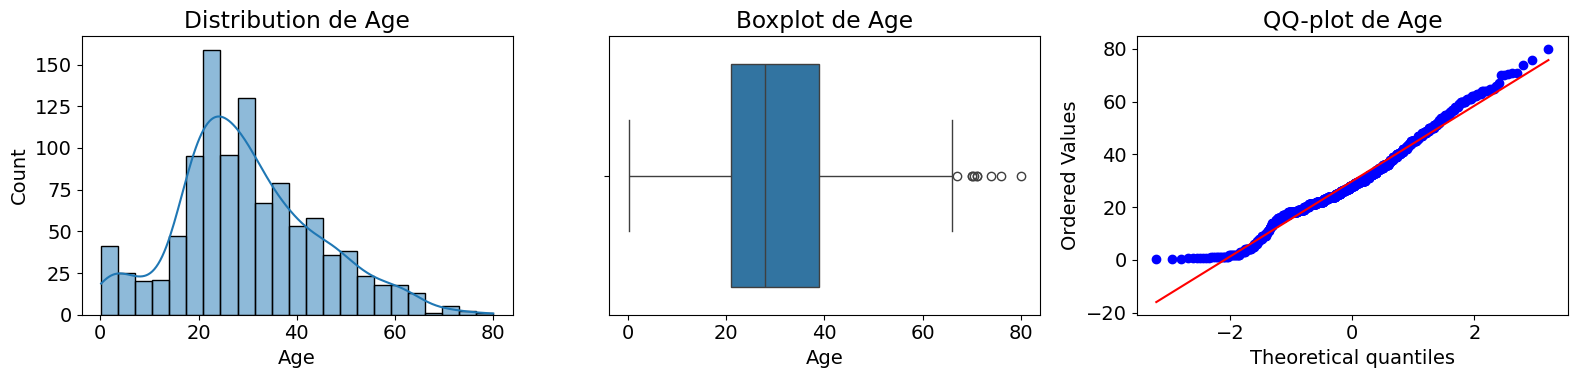

Missing values : 263
Skewness       : 0.408
Kurtosis       : 0.147


In [25]:
describe_numeric(df, "Age")

### SibSp - Sibling - Spouse

In [26]:
display(stats(df).loc[["SibSp"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
SibSp,int64,1309,0 (0%),7,0,891,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0


In [27]:
df["SibSp"].value_counts().sort_index()

SibSp
0    891
1    319
2     42
3     20
4     22
5      6
8      9
Name: count, dtype: int64

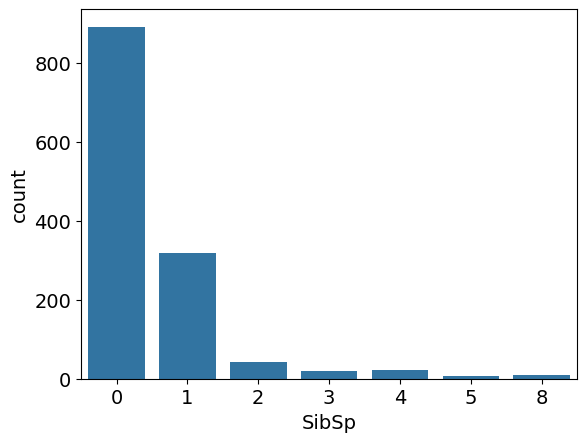

In [28]:


sns.countplot(
    data=df,
    x="SibSp"
)

plt.show()

In [29]:
print("skewness:", df["SibSp"].skew())
print("kurtosis:", df["SibSp"].kurtosis())

skewness: 3.844220342922907
kurtosis: 20.043251498181696


- Aucun nettoyage nécessaire.
- La variable ne contient aucune valeur manquante, aucune incohérence et les valeurs extrêmes observées correspondent à des situations réelles de voyage en famille nombreuse.
- Le feature engineering sera traité ultérieurement via FamilySize, IsAlone ou d'autres variables dérivées.

### Parch

In [30]:
display(stats(df).loc[["Parch"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Parch,int64,1309,0 (0%),8,0,1002,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0


In [31]:
df["Parch"].value_counts().sort_index()

Parch
0    1002
1     170
2     113
3       8
4       6
5       6
6       2
9       2
Name: count, dtype: int64

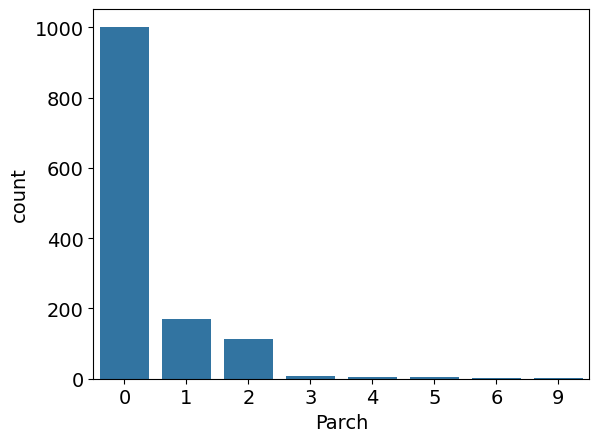

In [32]:
sns.countplot(
    data=df,
    x="Parch"
)

plt.show()

- Variable propre.
- Aucun traitement de nettoyage requis.
- L'intérêt principal de ces variables apparaîtra dans la phase de feature engineering avec des variables dérivées telles que FamilySize, IsAlone ou HasFamily.

### Ticket

In [33]:
display(stats(df).loc[["Ticket"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket,str,1309,0 (0%),929,CA. 2343,11,/,/,/,/,/,/,/


In [34]:
df["Ticket"].sample(10, random_state=42)

1148        363611
1049        110489
982         345498
808         248723
1195        383123
240           2665
1118        370368
596         248727
924     W./C. 6607
65            2661
Name: Ticket, dtype: str

In [35]:
df["Ticket"].duplicated().sum()

# beaucoup de ticket partagé

np.int64(380)

In [36]:
df["Ticket"].str.len().describe()

count    1309.000000
mean        6.790680
std         2.769516
min         3.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        18.000000
Name: Ticket, dtype: float64

<Axes: >

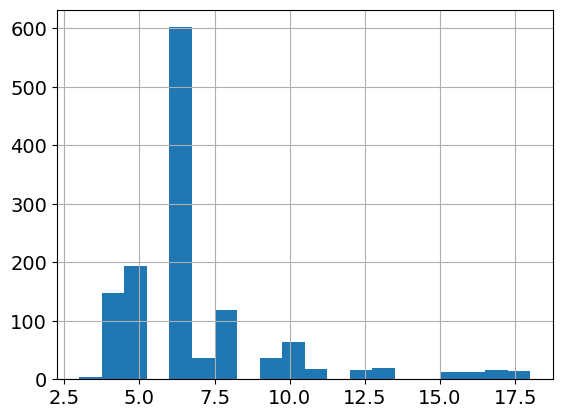

In [37]:
df["Ticket"].str.len().hist(bins=20)

In [38]:
df.loc[df["Ticket"].str.len() > 15, "Ticket"]

2         STON/O2. 3101282
115      STON/O 2. 3101294
131     SOTON/O.Q. 3101307
142       STON/O2. 3101279
173      STON/O 2. 3101280
210     SOTON/O.Q. 3101311
216       STON/O2. 3101283
243      STON/O 2. 3101275
363     SOTON/O.Q. 3101310
382      STON/O 2. 3101293
400      STON/O 2. 3101289
403       STON/O2. 3101279
414      STON/O 2. 3101269
429      SOTON/O.Q. 392078
433      STON/O 2. 3101274
465     SOTON/O.Q. 3101306
491       SOTON/OQ 3101317
511       SOTON/OQ 3101316
564      SOTON/O.Q. 392087
579      STON/O 2. 3101286
590      STON/O 2. 3101273
611     SOTON/O.Q. 3101305
636      STON/O 2. 3101292
664      STON/O 2. 3101285
729       STON/O2. 3101271
744      STON/O 2. 3101288
761       SOTON/O2 3101272
784     SOTON/O.Q. 3101312
816       STON/O2. 3101290
840       SOTON/O2 3101287
883       C.A./SOTON 34068
909       STON/O2. 3101270
933     SOTON/O.Q. 3101263
936      STON/O 2. 3101291
988      STON/O 2. 3101268
1050    SOTON/O.Q. 3101315
1102    SOTON/O.Q. 3101308
1

In [39]:
df[df["Ticket"].str.contains("LINE", na=False)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
179,180,0.0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S
271,272,1.0,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S
302,303,0.0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S
597,598,0.0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S


- Format hétérogène.
- Certains tickets sont purement numériques.
- D'autres contiennent un préfixe alphanumérique.
- Plusieurs passagers partagent le même ticket.
- Pas de valeur manquante.
- Pas de format incohérent.
- Pas de correction nécessaire.
- Du potentiel pour construire de nouvelle variable

### Fare - Prix du ticket (indépendant du nombre de personne)

In [40]:
display(stats(df).loc[["Fare"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Fare,float64,1308,1 (1%),281,8.05,60,33.295479,51.758668,0.0,7.8958,14.4542,31.275,512.3292


In [41]:
df.loc[df["Fare"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [42]:
fare_imputation = (
    df
    .groupby(["Pclass", "Embarked"])["Fare"]
    .median()
    .loc[(3, "S")]
)

df.loc[df["Fare"].isna(), "Fare"] = fare_imputation

In [43]:
df.loc[df["PassengerId"]==1044]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,8.05,NaN,S


,count,mean,std,min,25%,50%,75%,max
Fare,1309.0,33.276193,51.743584,0.0,7.8958,14.4542,31.275,512.3292


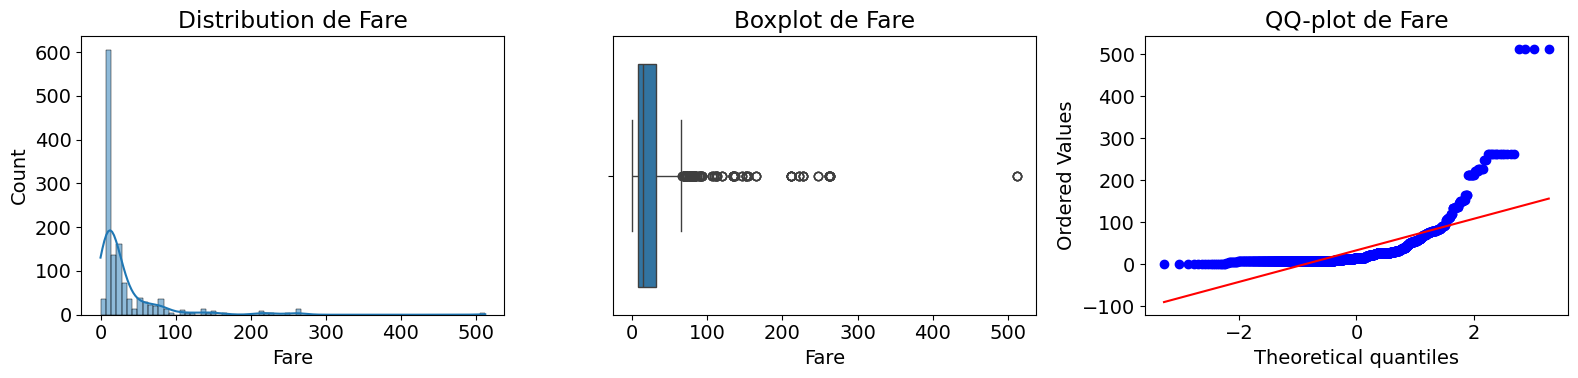

Missing values : 0
Skewness       : 4.369
Kurtosis       : 27.047


In [44]:
describe_numeric(df, "Fare")

- La moyenne et la médiane sont très similaires
- La variable Age présente une distribution relativement proche d'une loi normale.
- La skewness (0.41) indique une légère asymétrie positive tandis que la kurtosis (0.15) est très proche de celle d'une distribution normale.
- Le QQ-plot confirme que la majorité des observations suivent raisonnablement une distribution gaussienne, avec quelques écarts aux extrémités correspondant aux très jeunes enfants et aux personnes âgées.
- Aucune transformation particulière ne semble nécessaire.

### Cabin

In [45]:
display(stats(df).loc[["Cabin"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Cabin,str,295,1014 (78%),186,C23 C25 C27,6,/,/,/,/,/,/,/


In [46]:
df["Cabin"].sample(10, random_state=44)

47          NaN
41          NaN
760         NaN
976         NaN
557         NaN
177         C49
526         NaN
1229        NaN
550         C70
118     B58 B60
Name: Cabin, dtype: str

In [47]:
df["Cabin"].notna().sum()

np.int64(295)

In [48]:
df["Cabin"].nunique()

186

In [49]:
df["Cabin"].dropna().sample(20)

1263        B52 B54 B56
781                 B20
429                 E10
955     B57 B59 B63 B66
1000                  F
763             B96 B98
872         B51 B53 B55
1037                E46
627                  D9
1133                E34
1199                B69
618                  F4
1241            D10 D12
698                 C68
932                 D34
311     B57 B59 B63 B66
871                 D35
96                   A5
1213                 F2
717                E101
Name: Cabin, dtype: str

<Axes: >

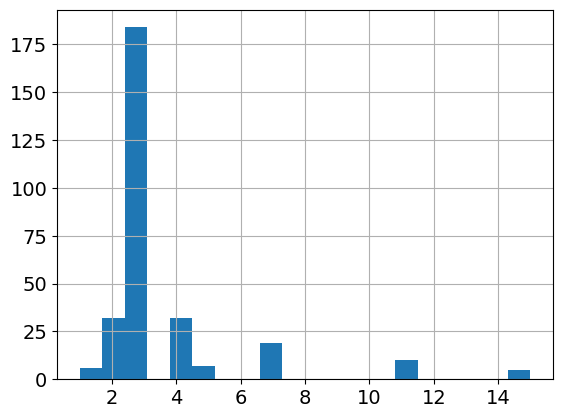

In [50]:
df["Cabin"].dropna().str.len().hist(bins=20)

In [51]:
df["Cabin"].dropna().str.match(
    r"^[A-Z]\d+(\s[A-Z]\d+)*$"
).value_counts()

Cabin
True     282
False     13
Name: count, dtype: int64

In [52]:
df["Cabin"].dropna().str[0].value_counts().sort_index()

Cabin
A    22
B    65
C    94
D    46
E    41
F    21
G     5
T     1
Name: count, dtype: int64

In [53]:
df[
    ~df["Cabin"].isna()
    &
    ~df["Cabin"].str.match(
        r"^[A-Z]\d+(\s[A-Z]\d+)*$"
    )
]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
75,76,0.0,3,"Moen, Mr. Sigurd Hansen",male,25.0,0,0,348123,7.6500,F G73,S
128,129,1.0,3,"Peter, Miss. Anna",female,NaN,1,1,2668,22.3583,F E69,C
292,293,0.0,2,"Levy, Mr. Rene Jacques",male,36.0,0,0,SC/Paris 2163,12.8750,D,C
327,328,1.0,2,"Ball, Mrs. (Ada E Hall)",female,36.0,0,0,28551,13.0000,D,S
339,340,0.0,1,"Blackwell, Mr. Stephen Weart",male,45.0,0,0,113784,35.5000,T,S
473,474,1.0,2,"Jerwan, Mrs. Amin S (Marie Marthe Thuillard)",female,23.0,0,0,SC/AH Basle 541,13.7917,D,C
699,700,0.0,3,"Humblen, Mr. Adolf Mathias Nicolai Olsen",male,42.0,0,0,348121,7.6500,F G63,S
715,716,0.0,3,"Soholt, Mr. Peter Andreas Lauritz Andersen",male,19.0,0,0,348124,7.6500,F G73,S
948,949,NaN,3,"Abelseth, Mr. Olaus Jorgensen",male,25.0,0,0,348122,7.6500,F G63,S
1000,1001,NaN,2,"Swane, Mr. George",male,18.5,0,0,248734,13.0000,F,S


- Les cabines suivent globalement un format composé d'une lettre représentant le pont et d'un numéro de cabine.
- Certains passagers possèdent plusieurs cabines.
- Quelques format particulier (F E69, F G73, etc.) redondant avec un F en premier
- 78% de NA est trop fort pour tenter une imputation. L’information est trop complexe pour reconstruire les cabines.
- On transformera cette absence d’information en signal.

### Embarked

In [54]:
display(stats(df).loc[["Embarked"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Embarked,str,1307,2 (1%),3,S,914,/,/,/,/,/,/,/


In [55]:
df["Embarked"].value_counts()

Embarked
S    914
C    270
Q    123
Name: count, dtype: int64

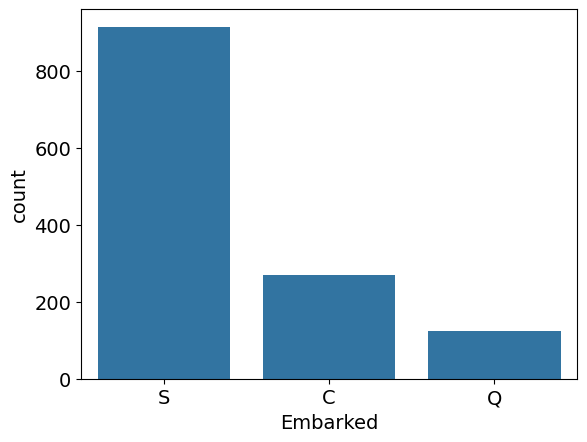

In [56]:
sns.countplot(
    data=df,
    x="Embarked"
)

plt.show()

In [57]:
df[df["Embarked"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [58]:
target_fare = 80

df.loc[
    (df["Pclass"] == 1)
    &
    (df["Fare"].between(70, 90)),
    [
        "PassengerId",
        "Sex",
        "Age",
        "Fare",
        "Embarked",
        "Cabin"
    ]
].sort_values("Fare")

,PassengerId,Sex,Age,Fare,Embarked,Cabin
540,541,female,36.0,71.0000,S,B22
745,746,male,70.0,71.0000,S,B22
1125,1126,male,39.0,71.2833,C,C85
1,2,female,38.0,71.2833,C,C85
1009,1010,male,36.0,75.2417,C,C6
1161,1162,male,46.0,75.2417,C,C6
366,367,female,60.0,75.2500,C,D37
1127,1128,male,64.0,75.2500,C,D37
939,940,female,60.0,76.2917,C,D15
218,219,female,32.0,76.2917,C,D15


In [59]:
df.loc[
    (df["Pclass"] == 1)
    &
    (df["Fare"].between(70, 90)),
    "Embarked"
].value_counts(dropna=False)

Embarked
C      29
S      25
Q       3
NaN     2
Name: count, dtype: int64

In [60]:
(
    df.groupby(["Pclass", "Embarked"])
      ["Fare"]
      .agg(["count", "median", "mean"])
      .sort_index()
)

count   median        mean
Pclass Embarked                            
1      C           141  76.7292  106.845330
       Q             3  90.0000   90.000000
       S           177  52.0000   72.148094
2      C            28  15.3146   23.300593
       Q             7  12.3500   11.735114
       S           242  15.3750   21.206921
3      C           101   7.8958   11.021624
       Q           113   7.7500   10.390820
       S           495   8.0500   14.422522

In [61]:
from titanic.cleaning import impute_embarked

df = impute_embarked(df, value="C")

- variable propre
- imputation du port C pour les deux valeurs manquantes, dont le profil ressemble plutôt aux passagers du port C que du port dominants S (cf. médiane).

## Statistiques

In [62]:
stats(df)

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,int64,1309,0 (0%),1309,1,1,655.0,378.020061,1.0,328.0,655.0,982.0,1309.0
Survived,float64,891,418 (32%),2,0.0,549,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,int64,1309,0 (0%),3,3,709,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
Name,str,1309,0 (0%),1307,"Connolly, Miss. Kate",2,/,/,/,/,/,/,/
Sex,str,1309,0 (0%),2,male,843,/,/,/,/,/,/,/
Age,float64,1046,263 (21%),98,24.0,47,29.881138,14.413493,0.17,21.0,28.0,39.0,80.0
SibSp,int64,1309,0 (0%),7,0,891,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
Parch,int64,1309,0 (0%),8,0,1002,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
Ticket,str,1309,0 (0%),929,CA. 2343,11,/,/,/,/,/,/,/
Fare,float64,1309,0 (0%),281,8.05,61,33.276193,51.743584,0.0,7.8958,14.4542,31.275,512.3292


- Données erronnées - Incorrect data
- Données manquantes - Missing data
- Données non normées - Unstandardized data
- Données obsolètes - Outdated data
- Doublons - Duplicates